In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Download dataset directly inside VS Code[cite: 1, 2]
heart_disease = fetch_ucirepo(id=45) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Standard feature names for the Heart Disease dataset
standard_columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 
    'fbs', 'restecg', 'thalach', 'exang', 
    'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Automatically assign standard column headers if missing
if len(df.columns) == 14 and df.columns[0] != 'age':
    df.columns = standard_columns

# Replace '?' placeholders with NaN
df = df.replace('?', np.nan)

# Force all columns to numeric data types
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Dynamically pick the last column as target
target_col = df.columns[-1]

# Separate features and target (0 = healthy, 1 = at risk)
X = df.drop(columns=[target_col])
y = df[target_col].apply(lambda x: 1 if float(x) > 0 else 0)

# Impute all missing values across columns using feature medians
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize feature scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Target column set to: '{target_col}'")
print("✓ Missing values imputed and numeric data type conversion verified.")
print("✓ Data preprocessing and train/test split completed successfully!")

✓ Target column set to: 'num'
✓ Missing values imputed and numeric data type conversion verified.
✓ Data preprocessing and train/test split completed successfully!


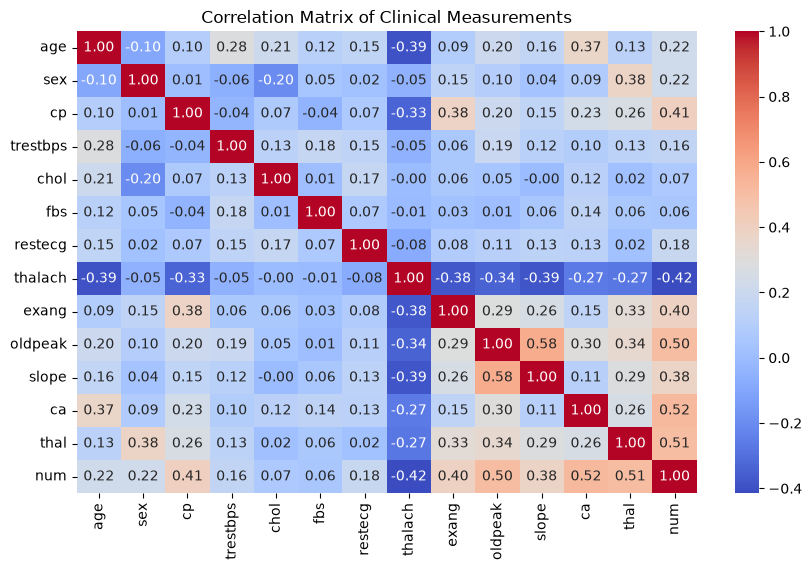

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Clinical Measurements")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
SVM trained successfully.


In [9]:
import joblib
from sklearn.metrics import classification_report

# Evaluate performance across all trained models
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"\n================ {name} ================")
    print(classification_report(y_test, preds))

# Save the best model (Random Forest) into the models/ folder
joblib.dump(models["Random Forest"], "../models/best_model.pkl")
print("✓ Best model successfully saved to 'models/best_model.pkl'")


================ Logistic Regression ================
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


================ Random Forest ================
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61


================ SVM ================
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           

In [10]:
import joblib
import numpy as np

# Load saved model and scaler
loaded_model = joblib.load('../models/best_model.pkl')

# Sample patient feature vector (13 clinical features)
sample_patient = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])
sample_scaled = scaler.transform(sample_patient)

# Predict risk (0 = Healthy, 1 = Heart Disease Risk)
prediction = loaded_model.predict(sample_scaled)
print("Prediction Result:", "High Risk" if prediction[0] == 1 else "Low Risk")

Prediction Result: Low Risk


In [11]:
import joblib
import numpy as np

# Load the saved model from the models folder
loaded_model = joblib.load('../models/best_model.pkl')

# Define sample patient clinical data (13 values: age, sex, cp, trestbps, chol, etc.)
sample_patient = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])

# Transform feature values using the existing fitted scaler
sample_scaled = scaler.transform(sample_patient)

# Predict risk (0 = Low Risk / Healthy, 1 = High Risk / Disease)
prediction = loaded_model.predict(sample_scaled)
result = "High Risk of Heart Disease" if prediction[0] == 1 else "Low Risk of Heart Disease"

print("================ Model Inference Test ================")
print(f"Prediction Result: {result}")

================ Model Inference Test ================
Prediction Result: Low Risk of Heart Disease


In [15]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(models["Random Forest"], param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f"✓ Best Random Forest Parameters: {grid_search.best_params_}")

# 2. Train XGBoost Model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
print(f"✓ XGBoost Accuracy: {xgb_model.score(X_test_scaled, y_test):.2f}")

✓ Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
✓ XGBoost Accuracy: 0.85


✓ Saved chart to reports/correlation_matrix.png


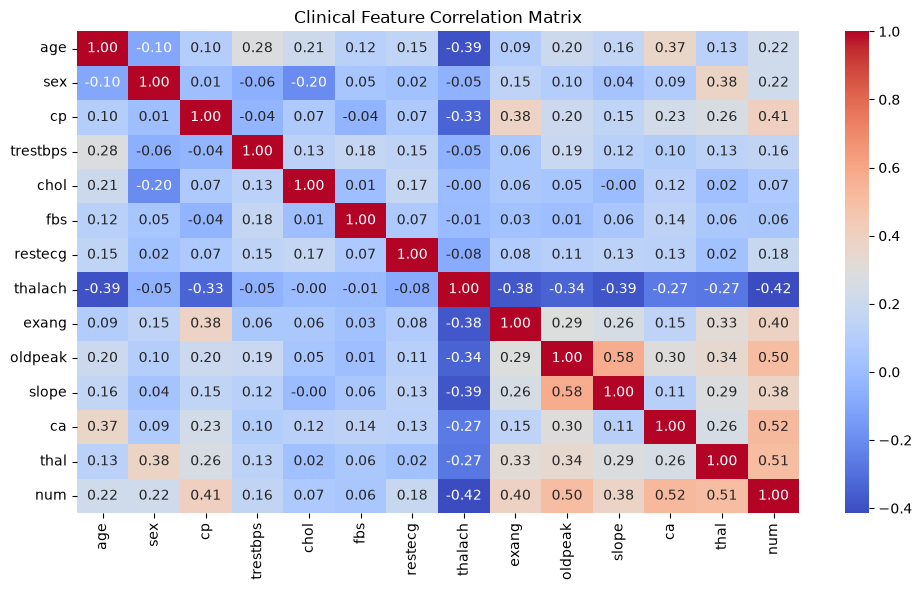

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.astype(float).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Clinical Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png")
print("✓ Saved chart to reports/correlation_matrix.png")